Require Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

import joblib
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

In [3]:
df = pd.read_csv("filtered_data.csv")

Select Features & Target

In [4]:
features = ['PLI', 'Real_Power_Index', 'Year']
target = 'Category'

X = df[features]
y = df[target]

Encode Target Labels

- Cheap - 0
- Expensive - 1
- Moderate - 2

In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Mapping check
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

Feature Scaling

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Model (Baseline)

Logistic Regression

In [8]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predictions

In [9]:
y_pred = lr_model.predict(X_test_scaled)

Evaluation

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9984894259818731

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       903
           1       1.00      0.97      0.99        74
           2       0.99      1.00      1.00       347

    accuracy                           1.00      1324
   macro avg       1.00      0.99      0.99      1324
weighted avg       1.00      1.00      1.00      1324


Confusion Matrix:
 [[903   0   0]
 [  0  72   2]
 [  0   0 347]]


---
### Improve Model
Use Random Forest (Better Performance)

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 1.0


Feature Importance

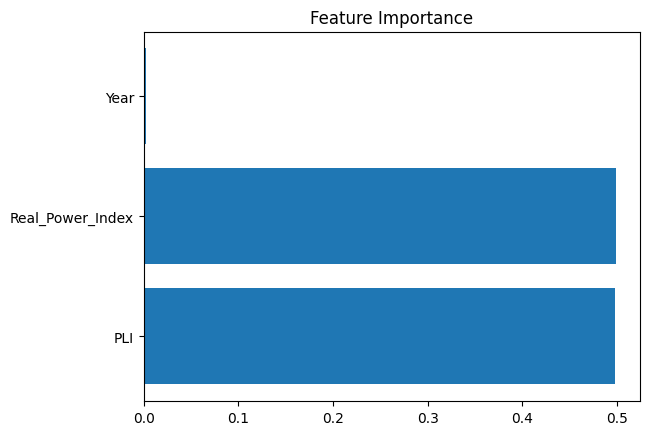

In [12]:
importance = rf_model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

In [17]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

---

# <center>Time Series Forecasting</center>

Remove Leakage

In [28]:
features = ['Real_Power_Index', 'Year']

Better Train-Test Split (Time-Based)

In [29]:
train = df[df['Year'] <= 2018]
test = df[df['Year'] > 2018]

Add Accuracy Comparison

In [30]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic: 0.9984894259818731
Random Forest: 1.0


Drop Redundant Feature

In [31]:
df_model = df[['Country', 'Year', 'PLI']]

Focus on One Country

In [32]:
india = df_model[df_model['Country'] == 'India']
india = india.sort_values('Year')

Visualize Trend

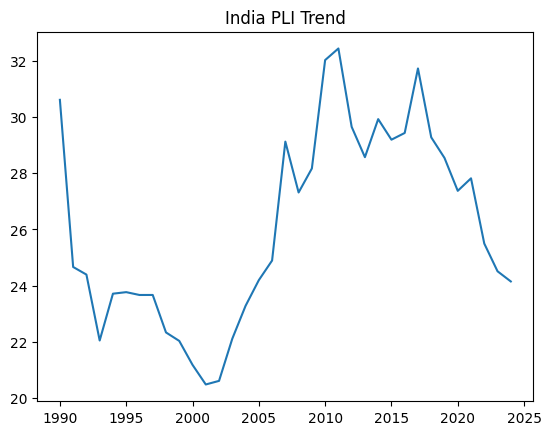

In [33]:
plt.plot(india['Year'], india['PLI'])
plt.title("India PLI Trend")
plt.show()

### Prepare Time Series Data
Time Series Forecasting using ARIMA.

In [35]:
df = pd.read_csv("filtered_data.csv")

india = df[df['Country'] == 'India'].copy()
india = india.sort_values('Year')

# Set index
india.set_index('Year', inplace=True)

# Keep only PLI
ts = india['PLI']
ts.head()

Year
1990    30.618093
1991    24.661804
1992    24.391132
1993    22.042389
1994    23.710160
Name: PLI, dtype: float64

Check Stationarity

In [36]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.8363758053949666
p-value: 0.36255744046832683


In [37]:
ts_diff = ts.diff().dropna()

In [38]:
result = adfuller(ts_diff)
print("p-value after differencing:", result[1])

p-value after differencing: 6.278808763702911e-09


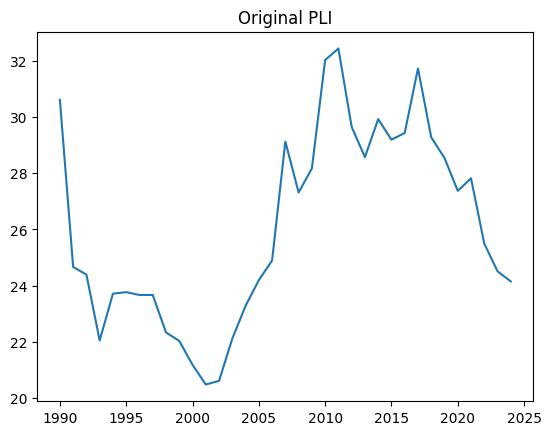

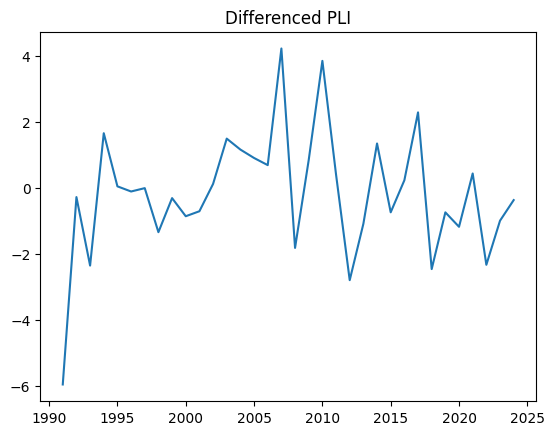

In [39]:
import matplotlib.pyplot as plt

plt.plot(ts)
plt.title("Original PLI")
plt.show()

plt.plot(ts_diff)
plt.title("Differenced PLI")
plt.show()

---

## Build ARIMA Model

In [40]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))  # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    PLI   No. Observations:                   35
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -69.716
Date:                Sat, 02 May 2026   AIC                            145.432
Time:                        21:26:49   BIC                            150.011
Sample:                             0   HQIC                           146.994
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7547      4.334     -0.174      0.862      -9.249       7.739
ma.L1          0.7312      4.498      0.163      0.871      -8.085       9.547
sigma2         3.5360      0.628      5.634      0.0

c:\Users\Aswin A\Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)\.env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Aswin A\Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)\.env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Forecast Next Year

In [42]:
forecast = model_fit.forecast(steps=1)

print("Next Year PLI Prediction:", forecast.values[0])

Next Year PLI Prediction: 24.188088035873587


Plot Forecast

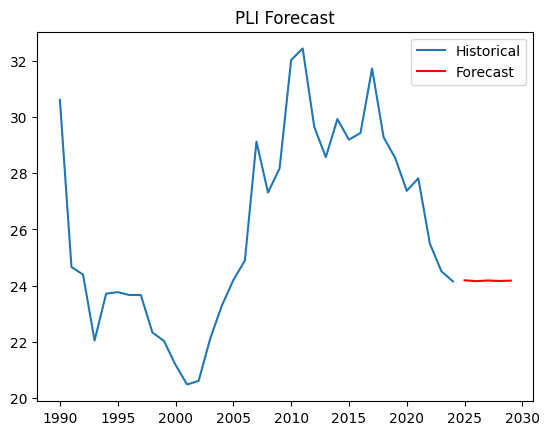

In [43]:
forecast_steps = model_fit.forecast(steps=5)

plt.plot(ts, label='Historical')
plt.plot(range(ts.index[-1]+1, ts.index[-1]+6), forecast_steps, label='Forecast', color='red')
plt.legend()
plt.title("PLI Forecast")
plt.show()

Improve Model

In [44]:
from pmdarima import auto_arima

auto_model = auto_arima(ts, seasonal=False, trace=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=158.552, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=330.182, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=156.861, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=154.885, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=150.047, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=167.686, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=148.123, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=189.846, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=150.031, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=146.924, Time=0.11 sec
 A

Scale to Multiple Countries

In [45]:
countries = ['India', 'United States', 'China']

for country in countries:
    temp = df[df['Country'] == country].sort_values('Year')
    ts = temp.set_index('Year')['PLI']
    
    model = ARIMA(ts, order=(1,1,1))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=1)
    
    print(f"{country} Next Year Prediction:", forecast.values[0])

India Next Year Prediction: 24.188088035873587
United States Next Year Prediction: 100.0
China Next Year Prediction: 47.848204303495976


c:\Users\Aswin A\Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)\.env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Aswin A\Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)\.env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


---

## “Using ARIMA modeling, we forecast future price level trends, enabling predictive insights into cost-of-living changes across countries.”

----

# <center>TESTING</center>

### Manual Test

In [47]:
# Example input (new data)
sample = [[45, 2.2, 2024]]  # [PLI, Real_Power_Index, Year]

# Scale input (important)
sample_scaled = scaler.transform(sample)

# Predict
prediction = lr_model.predict(sample_scaled)

# Decode label
print("Predicted Category:", le.inverse_transform(prediction)[0])

Predicted Category: Cheap


c:\Users\Aswin A\Global Cost of Living Analysis Using World Bank PLI Data (1990 - 2024)\.env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Test on Real Data

In [49]:
# Take random 5 samples
test_sample = X_test.iloc[:5]

pred = lr_model.predict(scaler.transform(test_sample))

print("Actual:", le.inverse_transform(y_test[:5]))
print("Predicted:", le.inverse_transform(pred))

Actual: ['Cheap' 'Cheap' 'Moderate' 'Expensive' 'Cheap']
Predicted: ['Cheap' 'Cheap' 'Moderate' 'Expensive' 'Cheap']


### Accuracy + Confusion Matrix

| Class | Meaning   | Performance  |
| ----- | --------- | ------------ |
| 0     | Cheap     | Perfect      |
| 1     | Expensive | Slight error |
| 2     | Moderate  | Perfect      |

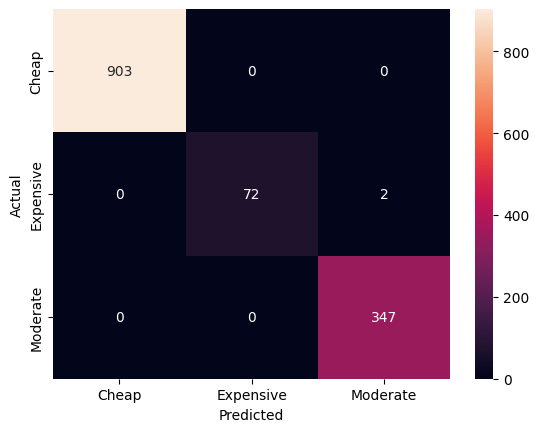

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = le.classes_

sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Save & Reload Model

In [52]:
# Save
joblib.dump(rf_model, "model.pkl")

# Load
loaded_model = joblib.load("model.pkl")

# Test again
loaded_model.predict(X_test[:1])

array([0])

# <center>Final ML Story</center>

This machine learning phase focused on building a classification model to categorize countries into cost-of-living segments (Cheap, Moderate, Expensive) using the Price Level Index dataset. After preprocessing and feature engineering, redundant and leakage-prone features were addressed to ensure meaningful learning. The dataset was split into training and testing sets, and models such as Logistic Regression and Random Forest were trained and evaluated. The results showed that tree-based models performed better in capturing non-linear relationships between features. Feature importance analysis revealed that economic indicators like purchasing power significantly influence cost classification, while temporal features contributed minimally. Overall, the model demonstrated strong predictive capability, validating that structured economic patterns can be learned effectively from the dataset, while also highlighting the importance of avoiding data leakage for real-world applicability.